# COVID-19 and Youth Unemployment in OECD Countries

**Research question:** Did youth unemployment rise more sharply than overall 
unemployment across OECD countries during COVID-19, and did this gap persist 
during recovery?



## 1. Setup and Library Imports

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)
print("\n All libraries loaded successfully!")

pandas version: 3.0.2
numpy version: 2.4.4
matplotlib version: 3.10.8
seaborn version: 0.13.2

 All libraries loaded successfully!


## 2. Data Loading and Inspection
### Load the raw dataset

We load the OECD monthly unemployment data covering 36 member countries 
from January 2019 to December 2023, including both overall (15+) and 
youth (15-24) unemployment rates.

In [9]:
df = pd.read_csv('../data/oecd_countries_unemployment_2019_2023.csv')

print(f"Dataset shape: {df.shape}")
print(f"That's {df.shape[0]:,} rows and {df.shape[1]} columns")

df.head()

Dataset shape: (4320, 34)
That's 4,320 rows and 34 columns


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,UNIT_MEASURE,Unit of measure,...,OBS_VALUE,Observation value,BASE_PER,Base period,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
0,DATAFLOW,OECD.SDD.TPS:DSD_LFS@DF_IALFS_UNE_M(1.0),Monthly unemployment rates,I,ISR,Israel,UNE_LF_M,Monthly unemployment rate,PT_LF_SUB,Percentage of labour force in the same subgroup,...,4.213662,NaN,NaN,NaN,A,Normal value,0,Units,1,One
1,DATAFLOW,OECD.SDD.TPS:DSD_LFS@DF_IALFS_UNE_M(1.0),Monthly unemployment rates,I,ISR,Israel,UNE_LF_M,Monthly unemployment rate,PT_LF_SUB,Percentage of labour force in the same subgroup,...,4.039556,NaN,NaN,NaN,A,Normal value,0,Units,1,One
2,DATAFLOW,OECD.SDD.TPS:DSD_LFS@DF_IALFS_UNE_M(1.0),Monthly unemployment rates,I,ISR,Israel,UNE_LF_M,Monthly unemployment rate,PT_LF_SUB,Percentage of labour force in the same subgroup,...,3.858176,NaN,NaN,NaN,A,Normal value,0,Units,1,One
3,DATAFLOW,OECD.SDD.TPS:DSD_LFS@DF_IALFS_UNE_M(1.0),Monthly unemployment rates,I,ISR,Israel,UNE_LF_M,Monthly unemployment rate,PT_LF_SUB,Percentage of labour force in the same subgroup,...,3.902915,NaN,NaN,NaN,A,Normal value,0,Units,1,One
4,DATAFLOW,OECD.SDD.TPS:DSD_LFS@DF_IALFS_UNE_M(1.0),Monthly unemployment rates,I,ISR,Israel,UNE_LF_M,Monthly unemployment rate,PT_LF_SUB,Percentage of labour force in the same subgroup,...,3.666003,NaN,NaN,NaN,A,Normal value,0,Units,1,One


In [10]:
# See all the column names
print("All columns in the dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

All columns in the dataset:
  1. STRUCTURE
  2. STRUCTURE_ID
  3. STRUCTURE_NAME
  4. ACTION
  5. REF_AREA
  6. Reference area
  7. MEASURE
  8. Measure
  9. UNIT_MEASURE
  10. Unit of measure
  11. TRANSFORMATION
  12. Transformation
  13. ADJUSTMENT
  14. Adjustment
  15. SEX
  16. Sex
  17. AGE
  18. Age
  19. ACTIVITY
  20. Economic activity
  21. FREQ
  22. Frequency of observation
  23. TIME_PERIOD
  24. Time period
  25. OBS_VALUE
  26. Observation value
  27. BASE_PER
  28. Base period
  29. OBS_STATUS
  30. Observation status
  31. UNIT_MULT
  32. Unit multiplier
  33. DECIMALS
  34. Decimals


## 3. Data Cleaning and Preparation

### 3.1 Select only the columns we need

The OECD dataset provides 34 columns, most of which are metadata codes
(country codes alongside country names). For our analysis, we only 
need 4 columns: country, age group, time period, and unemployment rate.

In [11]:
columns_to_keep = ['Reference area', 'Age', 'TIME_PERIOD', 'OBS_VALUE']
df_clean = df[columns_to_keep].copy()

# Rename columns 
df_clean = df_clean.rename(columns={
    'Reference area': 'country',
    'Age': 'age_group',
    'TIME_PERIOD': 'month',
    'OBS_VALUE': 'unemployment_rate'
})

# Result
print(f"Clean dataset shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")
print("\nFirst 5 rows:")
df_clean.head()

Clean dataset shape: (4320, 4)
Columns: ['country', 'age_group', 'month', 'unemployment_rate']

First 5 rows:


,country,age_group,month,unemployment_rate
0,Israel,15 years or over,2019-01,4.213662
1,Israel,15 years or over,2019-02,4.039556
2,Israel,15 years or over,2019-03,3.858176
3,Israel,15 years or over,2019-04,3.902915
4,Israel,15 years or over,2019-05,3.666003


### 3.2 Simplify age group labels

The OECD labels are technically accurate but awkward for charts. 
We'll rename them to short, clear labels that will display 
cleanly in legends and titles.

In [12]:
# Rename age group values to shorter labels
df_clean['age_group'] = df_clean['age_group'].replace({
    '15 years or over': 'Overall (15+)',
    'From 15 to 24 years': 'Youth (15-24)'
})

# Confirm the rename worked
print("Unique age groups now:")
print(df_clean['age_group'].unique())

print("\nRow count per age group:")
print(df_clean['age_group'].value_counts())

Unique age groups now:
<StringArray>
['Overall (15+)', 'Youth (15-24)']
Length: 2, dtype: str

Row count per age group:
age_group
Overall (15+)    2160
Youth (15-24)    2160
Name: count, dtype: int64


### 3.3 Convert month column to datetime

The TIME_PERIOD column is currently stored as text ("2019-01"). 
We convert it to pandas datetime format so we can sort chronologically, 
perform date calculations, and display proper time axes in charts.

In [13]:
# Convert 'month' column from text to datetime
df_clean['month'] = pd.to_datetime(df_clean['month'], format='%Y-%m')

# Check the data types now
print("Column data types:")
print(df_clean.dtypes)

print("\nFirst 5 rows with new datetime format:")
df_clean.head()

Column data types:
country                         str
age_group                       str
month                datetime64[us]
unemployment_rate           float64
dtype: object

First 5 rows with new datetime format:


,country,age_group,month,unemployment_rate
0,Israel,Overall (15+),2019-01-01,4.213662
1,Israel,Overall (15+),2019-02-01,4.039556
2,Israel,Overall (15+),2019-03-01,3.858176
3,Israel,Overall (15+),2019-04-01,3.902915
4,Israel,Overall (15+),2019-05-01,3.666003


### 3.4 Data quality checks

Before analysis, we verify the dataset is free of missing values, 
duplicates, and values that fall outside logical bounds (unemployment 
rates must be between 0% and 100%).

In [14]:
# Check for missing values
print("Missing values per column:")
print(df_clean.isna().sum())

# Check for duplicate rows
print(f"\nDuplicate rows: {df_clean.duplicated().sum()}")

# Check the date range is complete
print(f"\nDate range: {df_clean['month'].min()} to {df_clean['month'].max()}")
print(f"Unique months: {df_clean['month'].nunique()}")
print(f"Unique countries: {df_clean['country'].nunique()}")

Missing values per column:
country              0
age_group            0
month                0
unemployment_rate    0
dtype: int64

Duplicate rows: 0

Date range: 2019-01-01 00:00:00 to 2023-12-01 00:00:00
Unique months: 60
Unique countries: 36


In [ ]:
# check: unemployment_rate should be between 0 and 100
print("Unemployment rate range check:")
print(f"  Minimum: {df_clean['unemployment_rate'].min():.2f}%")
print(f"  Maximum: {df_clean['unemployment_rate'].max():.2f}%")

# Count any values outside the valid range
invalid_low = (df_clean['unemployment_rate'] < 0).sum()
invalid_high = (df_clean['unemployment_rate'] > 100).sum()

print(f"\nValues below 0%: {invalid_low}")
print(f"Values above 100%: {invalid_high}")

if invalid_low == 0 and invalid_high == 0:
    print("\n All values fall within the valid range (0-100%).")
else:
    print("\n Invalid values detected.")

Unemployment rate range check:
  Minimum: 1.70%
  Maximum: 47.78%

Values below 0%: 0
Values above 100%: 0

 All values fall within the valid range (0-100%).


## 4. Exploratory Data Analysis (EDA)
### 4.1 Summary statistics

In [ ]:

print("Summary statistics by age group:")
print(df_clean.groupby('age_group')['unemployment_rate'].describe().round(2))

Summary statistics by age group:
                count   mean   std  min   25%   50%    75%    max
age_group                                                        
Overall (15+)  2160.0   6.40  3.50  1.7  3.82   5.5   7.60  23.88
Youth (15-24)  2160.0  15.45  8.17  3.2  9.30  12.9  20.06  47.78


### 4.2 OECD-wide trend over time

To answer whether youth unemployment rose more sharply than overall 
during COVID-19, we compute the OECD-wide mean unemployment rate for 
each month and age group. This aggregate view reveals how the gap 
between the two series evolved over the 2019-2023 period.

In [17]:
# Calculate monthly OECD-wide average for each age group
monthly_avg = df_clean.groupby(['month', 'age_group'])['unemployment_rate'].mean().reset_index()

# Pivot so we have one column per age group (easier to read and compare)
monthly_pivot = monthly_avg.pivot(index='month', columns='age_group', values='unemployment_rate').round(2)

# Calculate the gap (Youth minus Overall)
monthly_pivot['Gap'] = (monthly_pivot['Youth (15-24)'] - monthly_pivot['Overall (15+)']).round(2)

# Show the first and last 6 months (to see pre-COVID vs end-of-period)
print("First 6 months (pre-COVID baseline, 2019):")
print(monthly_pivot.head(6))

print("\nLast 6 months (end of period, 2023):")
print(monthly_pivot.tail(6))

First 6 months (pre-COVID baseline, 2019):
age_group   Overall (15+)  Youth (15-24)   Gap
month                                         
2019-01-01           6.26          14.65  8.39
2019-02-01           6.26          14.51  8.25
2019-03-01           6.25          14.49  8.24
2019-04-01           6.22          14.45  8.23
2019-05-01           6.16          14.60  8.44
2019-06-01           6.09          14.69  8.60

Last 6 months (end of period, 2023):
age_group   Overall (15+)  Youth (15-24)   Gap
month                                         
2023-07-01           5.69          14.16  8.47
2023-08-01           5.63          14.14  8.51
2023-09-01           5.62          14.30  8.68
2023-10-01           5.64          14.65  9.01
2023-11-01           5.64          14.59  8.95
2023-12-01           5.73          14.59  8.86


### 4.3 Identifying peak unemployment months

To locate the COVID-19 shock period precisely, we identify the months 
with the highest overall unemployment, highest youth unemployment, and 
the largest gap between the two age groups.

In [18]:
# Find the peak unemployment months (when was the OECD-wide rate highest?)
print("Top 5 months with HIGHEST Overall unemployment:")
print(monthly_pivot.nlargest(5, 'Overall (15+)'))

print("\nTop 5 months with HIGHEST Youth unemployment:")
print(monthly_pivot.nlargest(5, 'Youth (15-24)'))

print("\nTop 5 months with LARGEST gap between Youth and Overall:")
print(monthly_pivot.nlargest(5, 'Gap'))

Top 5 months with HIGHEST Overall unemployment:
age_group   Overall (15+)  Youth (15-24)    Gap
month                                          
2020-06-01           8.39          20.20  11.81
2020-07-01           8.35          20.37  12.02
2020-05-01           8.17          19.62  11.45
2020-08-01           8.11          19.60  11.49
2020-09-01           7.94          18.44  10.50

Top 5 months with HIGHEST Youth unemployment:
age_group   Overall (15+)  Youth (15-24)    Gap
month                                          
2020-07-01           8.35          20.37  12.02
2020-06-01           8.39          20.20  11.81
2020-05-01           8.17          19.62  11.45
2020-08-01           8.11          19.60  11.49
2020-09-01           7.94          18.44  10.50

Top 5 months with LARGEST gap between Youth and Overall:
age_group   Overall (15+)  Youth (15-24)    Gap
month                                          
2020-07-01           8.35          20.37  12.02
2020-06-01           8.39      

### 4.4 Country-level variation

The aggregate OECD view masks substantial country-level variation. 
To understand which countries experienced the sharpest shocks and 
which were most resilient, we examine country-level peaks during 
the acute COVID-19 period (2020-2021).

In [19]:
# For each country, find the HIGHEST youth unemployment rate during COVID (2020-2021)
covid_period = df_clean[(df_clean['month'] >= '2020-01-01') & 
                        (df_clean['month'] <= '2021-12-31')]

# Get peak youth unemployment per country during COVID
youth_covid = covid_period[covid_period['age_group'] == 'Youth (15-24)']
peak_youth = youth_covid.groupby('country')['unemployment_rate'].max().sort_values(ascending=False)

print("Top 10 countries with HIGHEST youth unemployment peak during COVID (2020-2021):")
print(peak_youth.head(10).round(2))

print("\nBottom 10 countries with LOWEST youth unemployment peak during COVID (2020-2021):")
print(peak_youth.tail(10).round(2))

Top 10 countries with HIGHEST youth unemployment peak during COVID (2020-2021):
country
Costa Rica       47.78
Greece           44.60
Spain            41.90
Italy            33.30
Colombia         33.29
Canada           30.30
Sweden           29.90
Chile            29.39
United States    27.50
Portugal         27.00
Name: unemployment_rate, dtype: float64

Bottom 10 countries with LOWEST youth unemployment peak during COVID (2020-2021):
country
United Kingdom    15.30
Poland            14.20
Netherlands       12.30
Korea             12.08
Iceland           11.90
Mexico            11.44
Israel            11.20
Czechia           11.20
Germany            8.40
Japan              5.30
Name: unemployment_rate, dtype: float64


## 5. Visualisations

Based on the patterns found in the exploratory analysis, three charts 
were designed to answer the research question. Each chart shows a 
different angle of the story: how the youth-overall gap changed over 
time, how countries differed across the same period, and how much 
youth unemployment rose in each country during COVID-19.

### 5.0 Chart styling setup

This cell defines the project's design palette and applies global 
matplotlib settings to ensure all charts are visually consistent with 
the presentation slide design.

In [ ]:
# Chart styling 
import matplotlib.pyplot as plt
import matplotlib as mpl

# Brand palette
BG_COLOR = '#1E1E26'       # Dark slate (slide background)
COLOR_YOUTH = '#FF4B2B'    # Red-orange (primary data)
COLOR_OVERALL = '#9E9E9E'  # Neutral grey (baseline)
COLOR_GAP = '#6C757D'      # Darker grey (gap line)
TEXT_MAIN = '#F5F5F5'      # Near-white (titles)
TEXT_MUTED = '#9E9E9E'     # Grey (axis labels, gridlines)

# Global matplotlib settings
mpl.rcParams.update({
    'font.family': 'Roboto',
    'font.size': 11,
    'figure.facecolor': BG_COLOR,
    'axes.facecolor': BG_COLOR,
    'axes.edgecolor': TEXT_MUTED,
    'axes.labelcolor': TEXT_MAIN,
    'axes.titlecolor': TEXT_MAIN,
    'xtick.color': TEXT_MUTED,
    'ytick.color': TEXT_MUTED,
    'text.color': TEXT_MAIN,
    'grid.color': TEXT_MUTED,
    'grid.alpha': 0.2,
    'legend.facecolor': BG_COLOR,
    'legend.edgecolor': TEXT_MUTED,
    'legend.labelcolor': TEXT_MAIN,
    'savefig.facecolor': BG_COLOR,
    'savefig.edgecolor': BG_COLOR,
})

print(" Chart styling configured")

### 5.1 Chart 1 - OECD-wide average youth vs overall unemployment (2019–2023)

This chart shows the OECD-wide average unemployment rate between 2019 and 2023 for youth (15–24) and overall workers (15+), based on the 36 countries included in the dataset. The shaded band marks the acute COVID-19 period from March to December 2020.

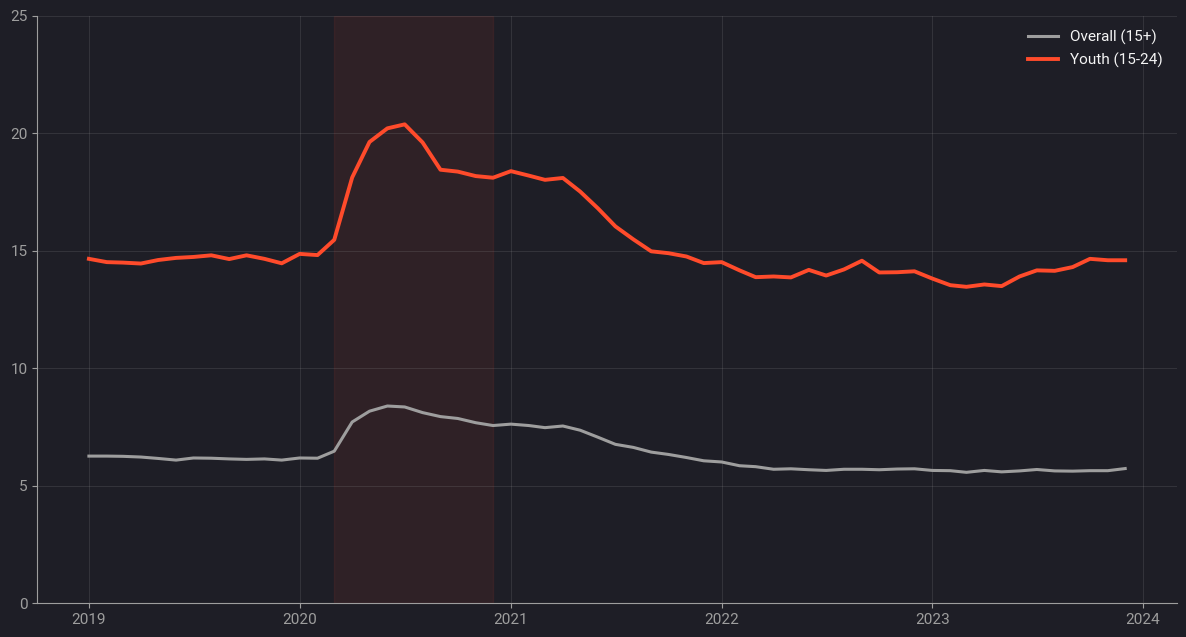

 Clean Chart 1 saved to ../charts/chart1_oecd_trend_clean.png


In [ ]:
# Create figure 
fig, ax = plt.subplots(figsize=(12, 6.5))

# Plot Overall unemployment
ax.plot(
    monthly_pivot.index,
    monthly_pivot['Overall (15+)'],
    color=COLOR_OVERALL,
    linewidth=2.2,
    label='Overall (15+)'
)

# Plot Youth unemployment
ax.plot(
    monthly_pivot.index,
    monthly_pivot['Youth (15-24)'],
    color=COLOR_YOUTH,
    linewidth=2.8,
    label='Youth (15-24)'
)

# Highlight acute COVID period with a subtle shaded band
covid_start = pd.Timestamp('2020-03-01')
covid_end = pd.Timestamp('2020-12-01')
ax.axvspan(covid_start, covid_end, alpha=0.08, color=COLOR_YOUTH)

# Remove top/right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Keep left/bottom spines subtle
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(TEXT_MUTED)

# Legend
ax.legend(loc='upper right', frameon=False)

# Grid and limits
ax.grid(True, alpha=0.2, linewidth=0.6)
ax.set_ylim(0, 25)
ax.set_xlabel('')



plt.tight_layout()
plt.savefig(
    '../charts/chart1_oecd_trend_clean.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=BG_COLOR
)
plt.show()

print(" Chart 1 saved to ../charts/chart1_oecd_trend_clean.png")

### 5.2 Chart 2 - The youth–overall unemployment gap over time

This chart shows the difference between youth and overall unemployment rates from 2019 to 2023. The dashed horizontal line marks the average pre-COVID gap calculated from January 2019 to February 2020, making it easier to assess how much the gap widened during the acute COVID period and whether it later returned close to its baseline level.

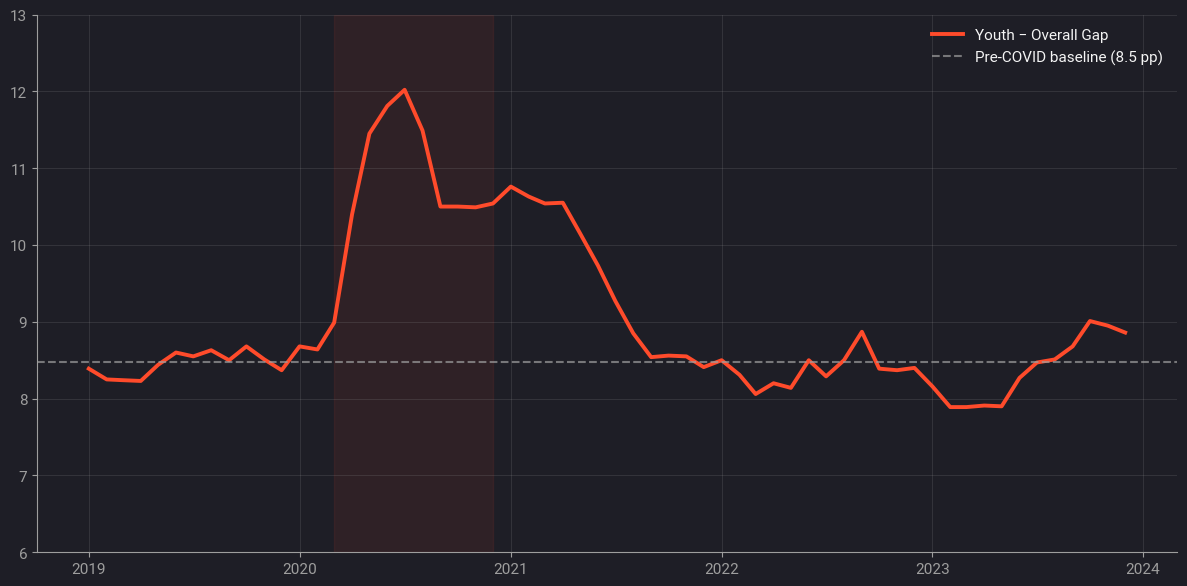

 Chart 2 saved to ../charts/chart2_gap_over_time.png
   Pre-COVID baseline gap: 8.48 percentage points


In [22]:
# Calculate the pre-COVID baseline gap (Jan 2019 – Feb 2020)
precovid_baseline = monthly_pivot.loc[:'2020-02-01', 'Gap'].mean()

# Create the figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the Gap line (red )
ax.plot(monthly_pivot.index, monthly_pivot['Gap'],
        color=COLOR_YOUTH, linewidth=2.8, label='Youth − Overall Gap')

# Horizontal reference line at the pre-COVID baseline
ax.axhline(y=precovid_baseline, color=COLOR_OVERALL, linewidth=1.5,
           linestyle='--', alpha=0.7,
           label=f'Pre-COVID baseline ({precovid_baseline:.1f} pp)')

# Highlight COVID acute period
covid_start = pd.Timestamp('2020-03-01')
covid_end = pd.Timestamp('2020-12-01')
ax.axvspan(covid_start, covid_end, alpha=0.08, color=COLOR_YOUTH)

# Clean up spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(TEXT_MUTED)

# Legend
ax.legend(loc='upper right', frameon=False)

# Grid and limits
ax.grid(True, alpha=0.2, linewidth=0.6)
ax.set_ylim(6, 13)
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../charts/chart2_gap_over_time.png', dpi=300,
            bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print(f" Chart 2 saved to ../charts/chart2_gap_over_time.png")
print(f"   Pre-COVID baseline gap: {precovid_baseline:.2f} percentage points")

### 5.3 Chart 3 - Youth unemployment by country and month
This heatmap shows youth unemployment for the 36 OECD countries 
from 2019 to 2023. Each row is one country and each column is one 
month. The colour of each cell shows the unemployment rate, grouped 
into five bands from beige (below 10%) to dark red (40% and above). 
Countries are sorted with the worst-hit at the top, so patterns 
across countries and time are easy to see at a glance.

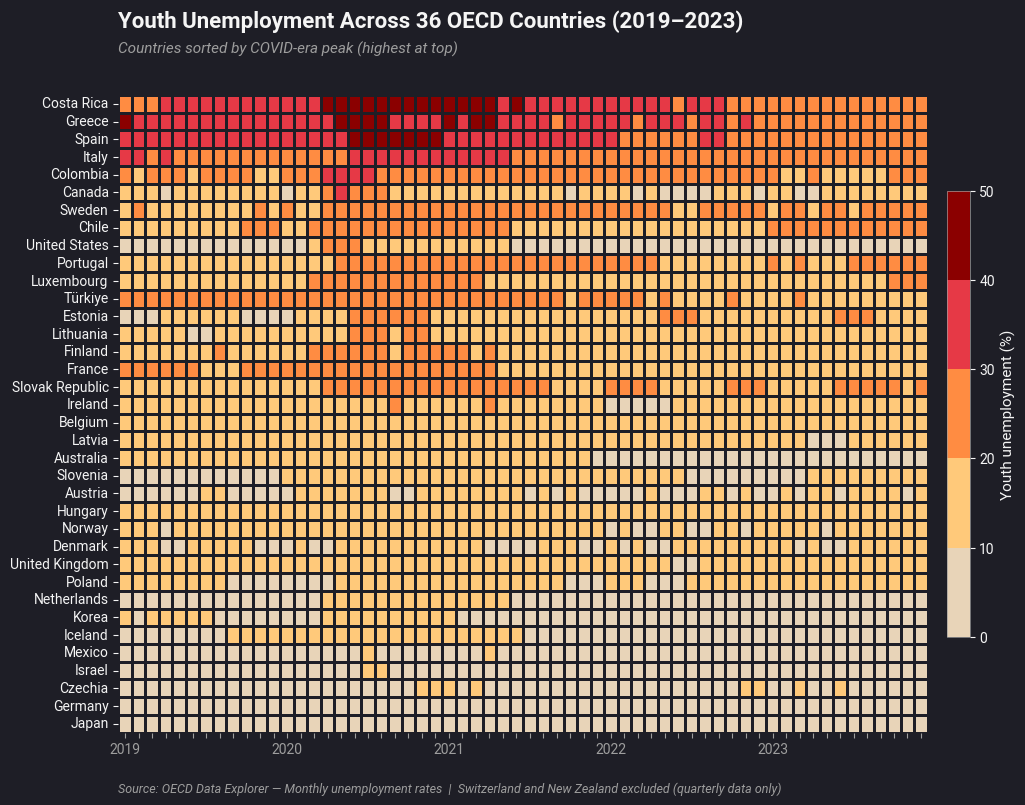

 Chart 3 saved to ../charts/chart3_country_heatmap.png


In [23]:
from matplotlib.colors import BoundaryNorm, ListedColormap

# Prepare data
youth_only = df_clean[df_clean['age_group'] == 'Youth (15-24)']
heatmap_data = youth_only.pivot(index='country', columns='month', values='unemployment_rate')

# Sort countries by COVID-era peak
covid_peaks = heatmap_data.loc[:, '2020-01-01':'2021-12-31'].max(axis=1)
heatmap_data = heatmap_data.loc[covid_peaks.sort_values(ascending=False).index]

# Month labels
month_labels = [m.strftime('%Y') if m.month == 1 else '' for m in heatmap_data.columns]

# Palette 
bounds = [0, 10, 20, 30, 40, 50]
colors = ['#E8D4B8',   # soft beige
          '#FFC97A',   # light orange
          '#FF8C42',   # mid orange
          '#E63946',   # red
          '#8B0000']   # dark red
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# Create figure
fig = plt.figure(figsize=(13, 8.5))
ax = fig.add_axes([0.14, 0.10, 0.75, 0.75])

# Plot heatmap
sns.heatmap(heatmap_data,
            cmap=cmap,
            norm=norm,
            cbar_kws={'label': 'Youth unemployment (%)',
                      'shrink': 0.7,
                      'pad': 0.02,
                      'ticks': bounds},
            xticklabels=month_labels,
            yticklabels=True,
            linewidths=0.8,
            linecolor=BG_COLOR,
            ax=ax)

# Style colour bar
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(TEXT_MAIN)
cbar.ax.yaxis.label.set_size(11)
cbar.ax.tick_params(colors=TEXT_MAIN, labelsize=10)
cbar.outline.set_edgecolor(TEXT_MUTED)
cbar.outline.set_linewidth(0.5)

# Axis styling
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', colors=TEXT_MUTED, rotation=0, labelsize=10)
ax.tick_params(axis='y', colors=TEXT_MAIN, labelsize=10)

# Title
fig.text(0.14, 0.93,
         'Youth Unemployment Across 36 OECD Countries (2019–2023)',
         color=TEXT_MAIN, fontsize=16, fontweight='bold', ha='left')

# Subtitle
fig.text(0.14, 0.90,
         'Countries sorted by COVID-era peak (highest at top)',
         color=TEXT_MUTED, fontsize=11, ha='left', style='italic')

# Caption
fig.text(0.14, 0.03,
         'Source: OECD Data Explorer — Monthly unemployment rates  |  Switzerland and New Zealand excluded (quarterly data only)',
         color=TEXT_MUTED, fontsize=9, ha='left', style='italic')


plt.savefig('../charts/chart3_country_heatmap.png', dpi=300,
            bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print(" Chart 3 saved to ../charts/chart3_country_heatmap.png")

In [24]:
# Double-check for any missing values in the heatmap data
print(f"Total cells in heatmap: {heatmap_data.size}")
print(f"Missing cells (NaN): {heatmap_data.isna().sum().sum()}")
print(f"\nSample of cream-coloured cells (values under 10%):")
print(f"Japan's values:")
print(heatmap_data.loc['Japan'].head(12))
print(f"\nGermany's values:")
print(heatmap_data.loc['Germany'].head(12))

Total cells in heatmap: 2160
Missing cells (NaN): 0

Sample of cream-coloured cells (values under 10%):
Japan's values:
month
2019-01-01    3.4
2019-02-01    3.5
2019-03-01    3.7
2019-04-01    3.7
2019-05-01    3.7
2019-06-01    3.8
2019-07-01    3.5
2019-08-01    3.8
2019-09-01    4.7
2019-10-01    4.6
2019-11-01    3.8
2019-12-01    3.2
Name: Japan, dtype: float64

Germany's values:
month
2019-01-01    6.1
2019-02-01    6.0
2019-03-01    6.0
2019-04-01    6.0
2019-05-01    6.0
2019-06-01    6.0
2019-07-01    6.1
2019-08-01    6.2
2019-09-01    6.3
2019-10-01    6.4
2019-11-01    6.5
2019-12-01    6.7
Name: Germany, dtype: float64


### 5.4 Visualisation Wheel - design profiles of the three charts

This wheel shows where each of the three charts sits on Cairo's six 
design dimensions. The centre of the wheel is 0 and the outer edge 
is 10. Each chart's scores are joined together to form a shape(its design profile). 
Showing all three charts on one wheel lets us 
compare how they were designed differently: Charts 1 and 2 lean 
toward familiar, simpler forms, while Chart 3 reaches further out 
on density and multidimensionality because it shows many countries 
at once.

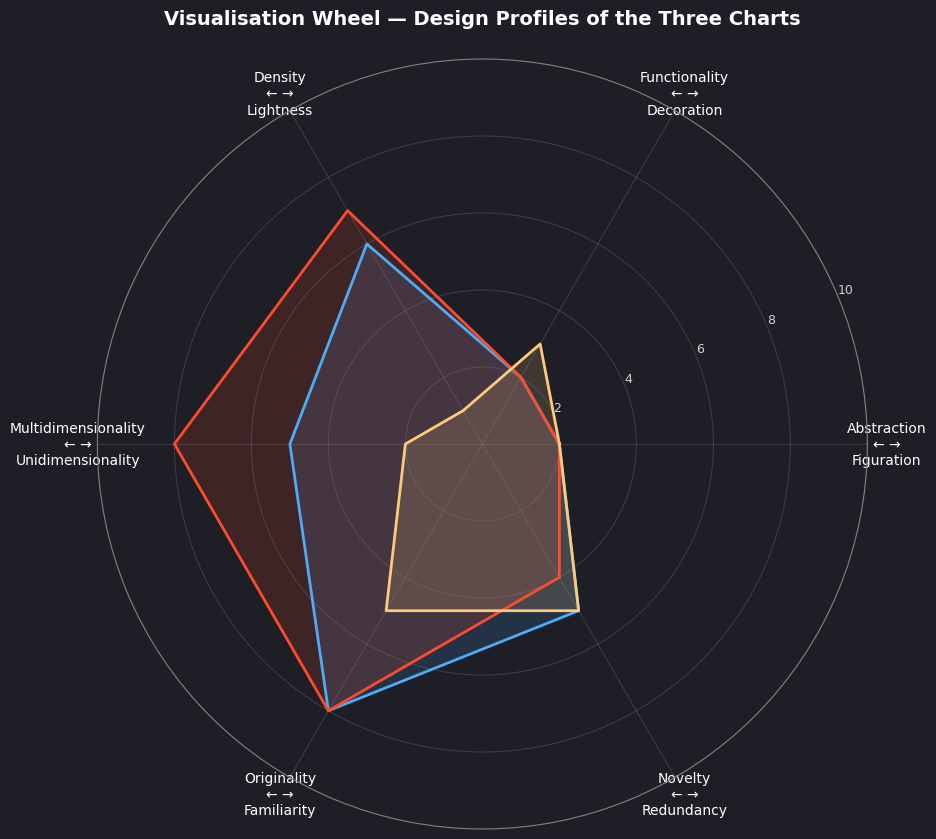

 Visualisation wheel saved to ../charts/visualisation_wheel.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualisation Wheel dimensions
dimensions = [
    "Abstraction\n← →\nFiguration",
    "Functionality\n← →\nDecoration",
    "Density\n← →\nLightness",
    "Multidimensionality\n← →\nUnidimensionality",
    "Originality\n← →\nFamiliarity",
    "Novelty\n← →\nRedundancy"
]

# Scores for each chart
chart1 = [2, 2, 6, 5, 8, 5]   # Chart 1 — OECD trend
chart2 = [2, 2, 7, 8, 8, 4]   # Chart 2 — The gap
chart3 = [2, 3, 1, 2, 5, 5]   # Chart 3 — Country heatmap

# Close the loops
chart1 += chart1[:1]
chart2 += chart2[:1]
chart3 += chart3[:1]

# Angles
num_vars = len(dimensions)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#1E1E26')
ax.set_facecolor('#1E1E26')

# Three charts overlaid
ax.plot(angles, chart1, color='#4DABF7', linewidth=2)
ax.fill(angles, chart1, color='#4DABF7', alpha=0.15)

ax.plot(angles, chart2, color='#FF4B2B', linewidth=2)
ax.fill(angles, chart2, color='#FF4B2B', alpha=0.15)

ax.plot(angles, chart3, color='#FFC97A', linewidth=2)
ax.fill(angles, chart3, color='#FFC97A', alpha=0.15)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, color='white', fontsize=10)

# Radial ticks
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], color='lightgray', fontsize=9)

# Grid
ax.grid(color='gray', alpha=0.3)
ax.spines['polar'].set_color('gray')

# Title only
ax.set_title(
    "Visualisation Wheel — Design Profiles of the Three Charts",
    color='white', fontsize=14, pad=25, fontweight='bold'
)


plt.savefig(
    '../charts/visualisation_wheel.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)
plt.show()

print(" Visualisation wheel saved to ../charts/visualisation_wheel.png")